# **Mental Health Score Prediction**

## 📌 **Project Overview**
Mental health has become one of the most important concerns among students in today's digital world. The rapid growth of social media platforms has significantly changed how students communicate, learn, and spend their leisure time. While these platforms provide opportunities for networking, education, and entertainment, excessive usage may negatively impact psychological well-being, academic performance, sleep quality, and stress levels.

This project aims to analyze the relationship between students' social media usage patterns, lifestyle habits, and mental health, and develop a Machine Learning model capable of predicting a student's **Mental Health Score** based on these factors.

Unlike a classification problem, where the output belongs to predefined categories, this is a **Supervised Machine Learning Regression** problem because the target variable is a continuous numerical value.

---

## 📌 **Problem Statement**

The objective of this project is to predict a student's **Mental_Health_Score** (approximately ranging from **3 to 10**) using demographic information, social media usage patterns, lifestyle habits, and stress levels.

The prediction can help educational institutions, researchers, and mental health professionals better understand which factors contribute most to students' psychological well-being and enable early intervention strategies.

---

## 📌 **Dataset Information**

**Dataset Name:** `Student_Social_Media_And_Mental_Health_Impact.csv`

The dataset contains information for **5,000 students** and includes **13 features** describing demographics, digital behavior, lifestyle, and mental health indicators.

### **Features Included**

| Feature | Description |
|----------|-------------|
| Age | Student's age |
| Gender | Gender of the student |
| Country | Country of residence |
| Avg_Daily_Usage_Hours | Average daily social media usage (hours) |
| Daily_Unlocks | Number of phone unlocks per day |
| Most_Used_Platform | Student's primary social media platform |
| Affects_Academic_Performance | Whether social media impacts academics |
| Sleep_Hours_Per_Night | Average sleep duration |
| Study_Hours_Per_Day | Daily study hours |
| Physical_Activity_Hours | Daily physical activity |
| Stress_Level | Reported stress level |
| Relationship_Status *(if available)* | Student's relationship status |
| Mental_Health_Score | **Target Variable** |

---

## 📌 **Target Variable**

**Mental_Health_Score**

- Continuous numerical value
- Approximate range: **3 – 10**
- Higher score generally indicates better mental well-being

Since the target is numerical, this project falls under **Regression Analysis**.

---

## 📌 **Machine Learning Workflow**

This project follows the complete Machine Learning pipeline:

1. Data Collection
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Data Preprocessing
7. Train-Test Split
8. Model Building
9. Model Evaluation
10. Model Comparison
11. Final Prediction

---

## 📌 **Evaluation Metrics**

The regression models will be evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score (Coefficient of Determination)

These metrics will help determine how accurately the model predicts students' mental health scores.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Loading the Dataset**

In [2]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [3]:
df

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [4]:
df.shape

(5000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


**Observations:** `Gender`, `Country`, `Academic_Level`, `Most_Used_Platform`, `Purpose_Of_Use` have object Dtype, which has to be changed and encoded accordingly.

In [6]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


**Data Validation:** Most feature values fall within expected ranges. However, the `Physical_Activity_Hours` column contains a minimum value of -0.4, which is not physically meaningful since activity duration cannot be negative. This indicates a data entry or recording error rather than a valid observation. Instead of overlooking this anomaly, it will be addressed appropriately during the Data Cleaning phase to ensure data quality and maintain the integrity of the analysis.

In [7]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


**Duplicate Rows Check:** The dataset contains no duplicate records, so no duplicate removal was required. Performing this validation is an essential data preprocessing step, as duplicate observations can introduce bias into the model by disproportionately weighting repeated samples and potentially affecting overall model performance.

## **Exploratory Data Analysis (EDA)**

### **Distribution of the target** `(Mental_Health_Score)`

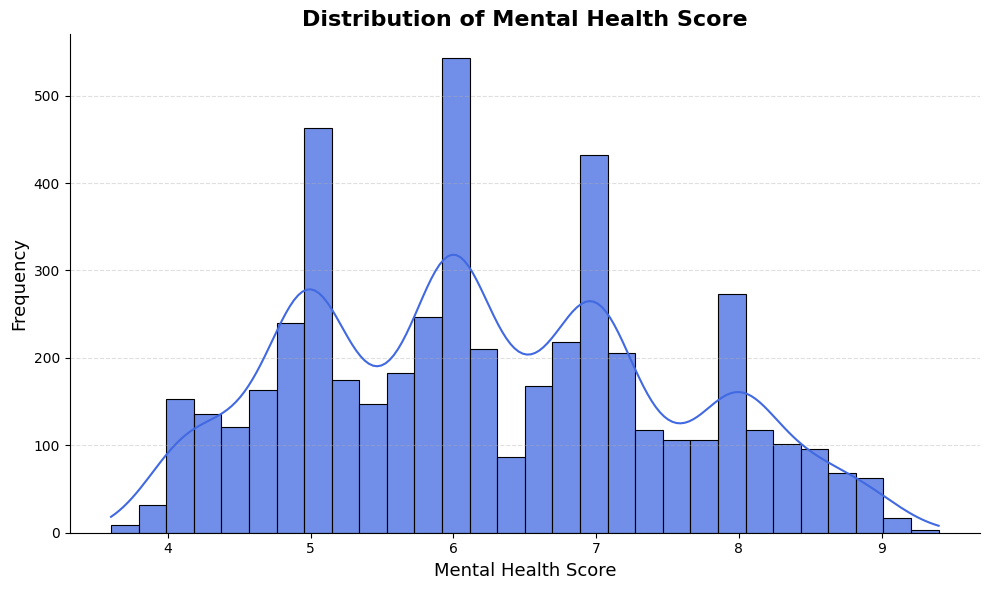

In [8]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Mental_Health_Score',
    bins=30,
    kde=True,
    color='royalblue',
    edgecolor='black',
    alpha=0.75,
    linewidth=0.8
)

plt.title('Distribution of Mental Health Score', fontsize=16, fontweight='bold')
plt.xlabel('Mental Health Score', fontsize=13)
plt.ylabel('Frequency', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

## **Correlation heatmap**

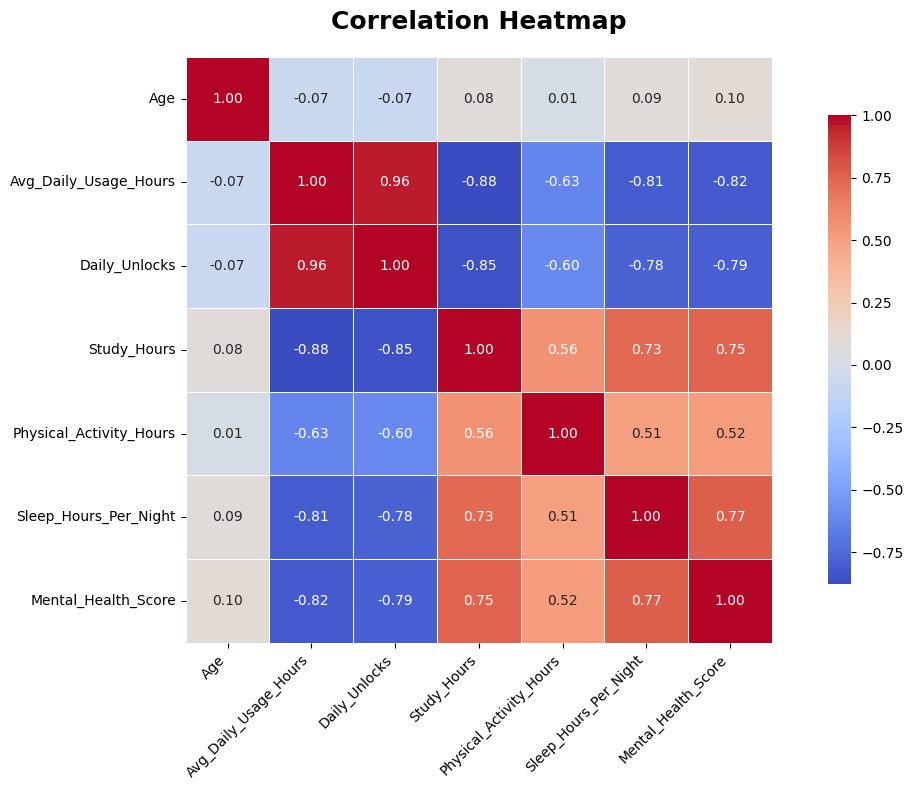

In [9]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap", fontsize=18, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

## **Stress Level vs Mental Health Score**

In [10]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

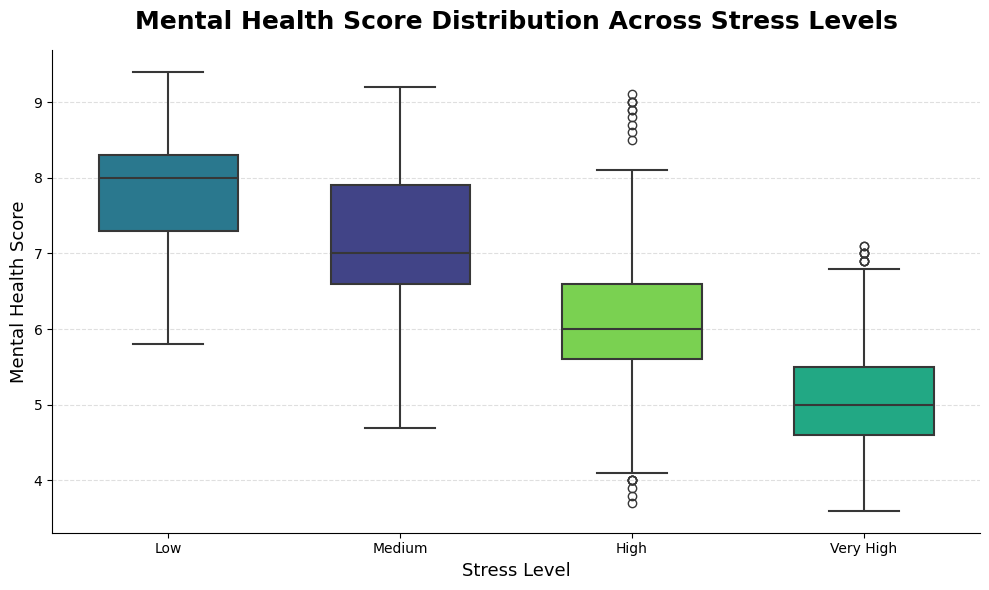

In [11]:
order = ['Low', 'Medium', 'High', 'Very High']
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='Stress_Level',
    y='Mental_Health_Score',
    data=df,
    order=order,
    palette='viridis',
    hue='Stress_Level',
    saturation=1,
    width=0.6,
    linewidth=1.5
)

plt.title(
    'Mental Health Score Distribution Across Stress Levels',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Stress Level', fontsize=13)
plt.ylabel('Mental Health Score', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

## **Daily Usage Hours vs Mental Health Score**

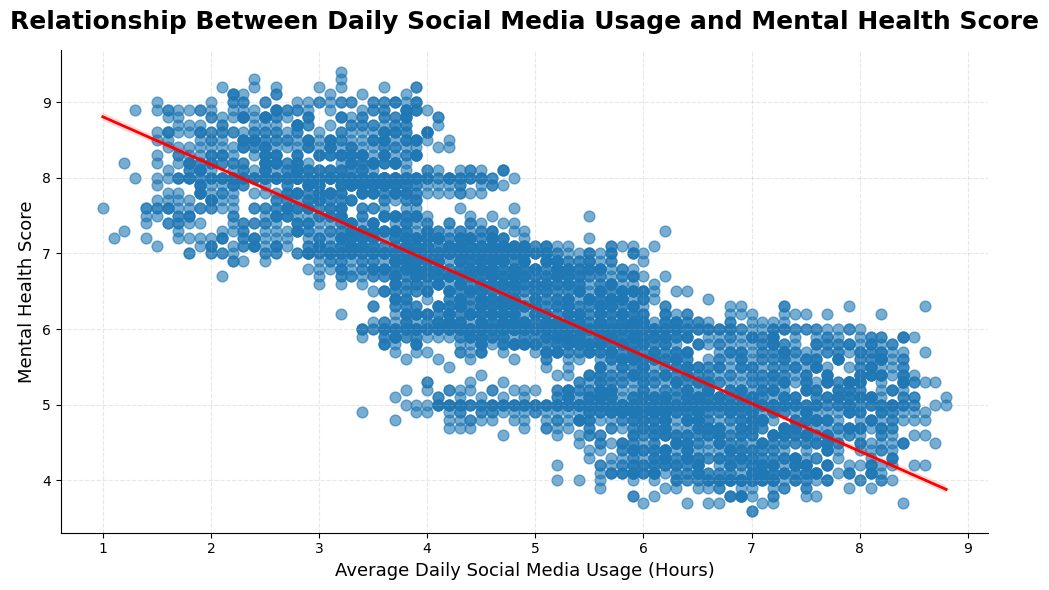

In [12]:
plt.figure(figsize=(10, 6))

sns.regplot(
    x='Avg_Daily_Usage_Hours',
    y='Mental_Health_Score',
    data=df,
    scatter_kws={
        'alpha': 0.6,
        's': 60
    },
    line_kws={
        'color': 'red',
        'linewidth': 2
    }
)

plt.title(
    'Relationship Between Daily Social Media Usage and Mental Health Score',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Average Daily Social Media Usage (Hours)', fontsize=13)
plt.ylabel('Mental Health Score', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

## **Sleep Hours vs Mental Health Score**

In [13]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

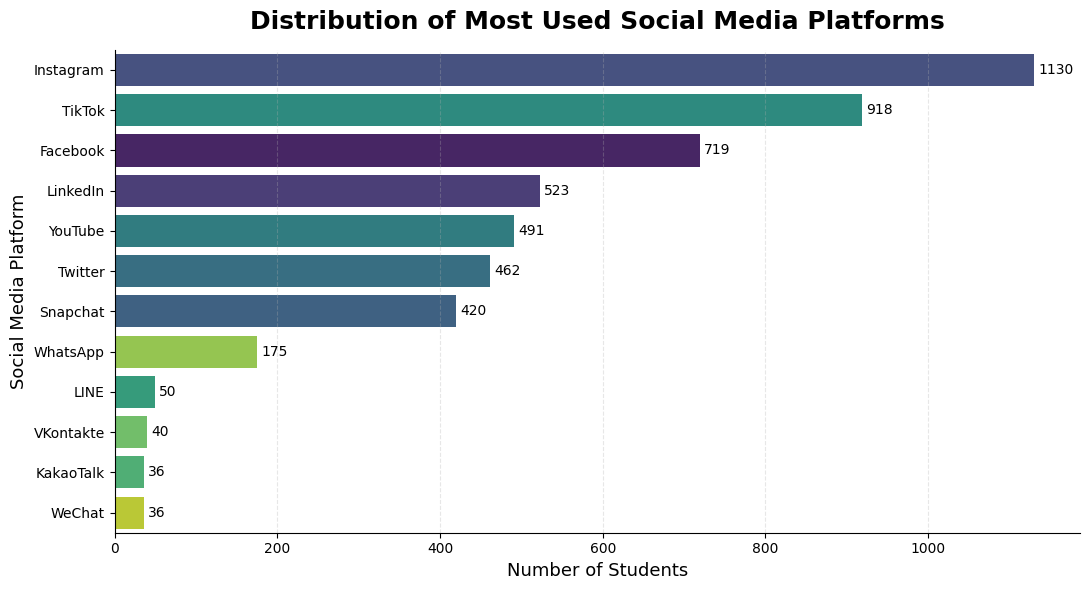

In [14]:
plt.figure(figsize=(11, 6))

ax = sns.countplot(
    y='Most_Used_Platform',
    data=df,
    order=df['Most_Used_Platform'].value_counts().index,
    hue='Most_Used_Platform',
    palette='viridis',
    legend=False
)

plt.title(
    'Distribution of Most Used Social Media Platforms',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Number of Students', fontsize=13)
plt.ylabel('Social Media Platform', fontsize=13)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

sns.despine()
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## **Most Used Platform (count)**

In [15]:
df['Most_Used_Platform'].value_counts()

,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


## **Checking Outliers**

In [16]:
num_features = df.select_dtypes(include='number')

Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((num_features < (lower_bound)) | (num_features > (upper_bound))).any(axis=1)
print(outliers.sum())

24


In [17]:
df = df.drop_duplicates()

In [18]:
df

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [19]:
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

/tmp/ipykernel_676/595824244.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)


**Handling Invalid Values:** Instead of removing the affected row, the negative value in `Physical_Activity_Hours` was corrected using `clip(lower=0)`, which replaces any value below 0 with the nearest valid boundary (0 hours). This approach preserves the remaining information in the record—such as age, study hours, stress level, and other relevant features—thereby avoiding unnecessary data loss. Discarding an entire observation due to a single invalid value would reduce the available training data without justification.

**Feature Retention:** No columns were removed from the dataset, as each feature has a plausible relationship with mental health prediction. Additionally, prior data quality checks confirmed that none of the columns were entirely missing, constant, or otherwise unsuitable for analysis. Retaining all relevant features ensures that the model can leverage the complete set of available information during training.

In [20]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


## **Checking Skewness**

In [21]:
num_features.skew()

,0
Age,0.155325
Avg_Daily_Usage_Hours,0.005606
Daily_Unlocks,0.002351
Study_Hours,0.435819
Physical_Activity_Hours,0.039971
Sleep_Hours_Per_Night,0.124050
Mental_Health_Score,0.206567


## **Feature Engineering**

* **Country Grouping:** The `Country` feature originally contained
111 unique categories, making it a high-cardinality categorical variable. Applying one-hot encoding directly would generate over 110 sparse binary columns, increasing the dimensionality of the dataset, adding computational overhead, and potentially reducing model performance due to sparsity.

* Rather than removing the feature altogether, a frequency-based grouping strategy was applied. The 10 most frequently occurring countries were retained as individual categories, while all remaining countries were consolidated into a single `Other` category. This approach preserves meaningful geographical information—such as differences in cultural, socioeconomic, educational, and lifestyle factors that may influence mental health—while significantly reducing noise and feature dimensionality.

* This transformation achieves an effective balance between information retention and model efficiency, enabling the model to capture relevant patterns without being adversely affected by the high cardinality of the original feature.

In [22]:
top_countries = df['Country'].value_counts().index[:10].to_list()

In [23]:
def group_country(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [24]:
df['Group_Country'] = df['Country'].apply(group_country)

/tmp/ipykernel_676/924677688.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Group_Country'] = df['Country'].apply(group_country)


In [25]:
df['Group_Country'].value_counts()

,count
Group_Country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


## **Encoding Strategy**

* Before applying any encoding techniques, it is important to determine the most appropriate encoding method for each categorical feature. Selecting the correct encoding strategy is essential, as it directly influences how effectively machine learning algorithms can interpret categorical data.

* **Ordinal Encoding:** The `Stress_Level` feature was encoded using Ordinal Encoding because its categories possess a meaningful hierarchical order `(Low < Medium < High < Very High)`. Exploratory Data Analysis (EDA) also indicated a gradual decline in mental health scores as stress levels increased. Assigning ordered numerical values preserves this inherent relationship, allowing the model to capture the progression of stress intensity.

* **One-Hot Encoding:** The remaining categorical features— `Gender`, `Academic_Level`, `Most_Used_Platform`, `Purpose_Of_Use`, and `Country_Grouped` — were encoded using One-Hot Encoding. These variables represent nominal categories with no intrinsic ordering; therefore, assigning numerical labels could introduce unintended ordinal relationships. One-Hot Encoding creates independent binary indicators for each category, ensuring that the model treats all categories as distinct and equally important.

* **Implementation:** Both encoding techniques were integrated within a single `ColumnTransformer` pipeline. This approach provides a structured and reusable preprocessing workflow, ensuring that the same transformations are applied consistently during both model training and inference, thereby improving reproducibility and reducing the risk of data preprocessing inconsistencies.

## **Train–Test Split**

**Purpose of Data Splitting:** The dataset is divided into training and testing subsets to evaluate the model's ability to generalize to unseen data. Assessing model performance on the same data used for training can produce overly optimistic results, as the model may simply memorize patterns rather than learn relationships that generalize to new observations.

**Split Ratio:** A standard 80:20 train–test split was adopted for this project. Given the dataset size of approximately 5,000 observations, this allocation provides sufficient data for model training while reserving around 1,000 unseen samples for a reliable and unbiased performance evaluation. This ratio offers an effective balance between learning capacity and evaluation quality.

**Preventing Data Leakage:** The train–test split was performed before fitting any preprocessing steps, such as encoding or feature scaling. This is a critical best practice in machine learning, as applying preprocessing to the entire dataset before splitting can introduce data leakage, allowing information from the test set to influence the training process. By fitting all preprocessing transformations exclusively on the training data and subsequently applying them to the test data, the evaluation remains fair, unbiased, and representative of real-world model performance.

In [26]:
from sklearn.model_selection import train_test_split

skews_cols = ['Study_Hours']
other_numeric_cols = ['Age' ,'Avg_Daily_Usage_Hours' ,'Daily_Unlocks' ,'Physical_Activity_Hours' ,'Sleep_Hours_Per_Night' ]
ordinal_cols = ['Stress_Level']
nominal_cols = ['Gender' ,'Academic_Level' ,'Group_Country' ,'Most_Used_Platform' ,'Purpose_Of_Use']

feature_cols = skews_cols + other_numeric_cols + ordinal_cols + nominal_cols
X = df[feature_cols]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

## **Preprocessing Using ColumnTransformer**

The dataset contains different types of features, each requiring a preprocessing strategy tailored to its characteristics. To ensure consistency and maintainability, all preprocessing steps were implemented using a ColumnTransformer, which applies the appropriate transformation pipeline to each feature group within a single unified workflow.

**Skewed Numerical Feature:** The `Study_Hours` feature exhibited a skewed distribution and was processed using the following sequence: missing value imputation, `log1p` transformation to reduce skewness, and standardization using a scaler. This transformation helps normalize the feature distribution and improves compatibility with machine learning algorithms that perform better with approximately normally distributed inputs.

**Other Numerical Features:** The remaining numerical variables underwent missing value imputation followed by feature scaling. Since these features did not display significant skewness, additional transformations were unnecessary.

**Ordinal Categorical Feature:** The `Stress_Level` feature was processed through missing value imputation and Ordinal Encoding using a predefined category order (Low < Medium < High < Very High). Preserving this natural ordering allows the model to capture the progressive relationship between stress intensity and mental health.

**Nominal Categorical Features:** The nominal categorical variables— `Gender`, `Academic_Level`, `Most_Used_Platform`, `Purpose_Of_Use`, and `Country_Grouped` — were processed using missing value imputation followed by One-Hot Encoding, ensuring that no artificial ordinal relationships are introduced among categories.

**Handling Missing Values:** Although the current dataset contains no missing values, a `SimpleImputer` was included in every preprocessing pipeline. Incorporating imputation at this stage improves the robustness of the workflow by ensuring it can handle incomplete data encountered during future predictions or deployment, without requiring modifications to the preprocessing logic.

**Unified Preprocessing Pipeline:** The `ColumnTransformer` combines all preprocessing operations into a single reusable object. During model training, each transformation is learned exclusively from the training data and then applied consistently to both training and testing datasets. This design improves reproducibility, minimizes the risk of preprocessing errors, prevents data leakage, and provides a scalable pipeline suitable for real-world machine learning applications.

## **Building a Pipeline**

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer

# 1. Skewed Features
skew_pipeline = Pipeline(steps=[
    ('log_trasformation', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

# 2. Numeric Features
plain_numeric_pipeline = Pipeline(steps=[
    ('scale', StandardScaler())
])

# 3. Ordinal Features
ordinal_pipeline = Pipeline(steps=[
    ('ordinal_encoder', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

# 4. Nominal Features
nominal_pipeline = Pipeline(steps=[
    ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('skew_pipeline', skew_pipeline, skews_cols),
    ('plain_numeric_pipeline', plain_numeric_pipeline, other_numeric_cols),
    ('ordinal_pipeline', ordinal_pipeline, ordinal_cols),
    ('nominal_pipeline', nominal_pipeline, nominal_cols)
])

preprocessor

ColumnTransformer(transformers=[('skew_pipeline',
                                 Pipeline(steps=[('log_trasformation',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scale', StandardScaler())]),
                                 ['Study_Hours']),
                                ('plain_numeric_pipeline',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('ordinal_pipeline',
                                 Pipeline(steps=[('ordinal_encoder',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('nominal_pipeline',
                                 Pipeline(steps=[('one_hot_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Academic_Level', 'Group_Country',
                                  'Most_Used_Platform', 'Purpose_Of_Use'])])

## **Baseline: Linear Regression**

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_pred_train = lr_pipeline.predict(X_train)

lr_r2_testing = r2_score(y_test, lr_pred)
lr_r2_training = r2_score(y_train, lr_pred_train)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)

print('R2 Score (Testing):', lr_r2_testing)
print('R2 Score (Training):', lr_r2_training)
print('MAE:', lr_mae)
print('MSE:', lr_mse)

R2 Score (Testing): 0.7397944617433021
R2 Score (Training): 0.7236771199387538
MAE: 0.5361775634720182
MSE: 0.45701905273487986


## **Random Forest (default settings)**

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
rf_preds_train = rf_pipeline.predict(X_train)

rf_r2_testing = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_train)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_mse = mean_squared_error(y_test, rf_preds)

print('R2 Score (Testing):', rf_r2_testing)
print('R2 Score (Training):', rf_r2_training)
print('MAE:', rf_mae)
print('MSE:', rf_mse)

R2 Score (Testing): 0.8779515649288515
R2 Score (Training): 0.9808758969726775
MAE: 0.34715970000000007
MSE: 0.2143630783483333


## **Hyperparameter Tuning of the Random Forest Model**

To optimize the performance of the Random Forest Regressor, hyperparameter tuning was performed using `RandomizedSearchCV`. Since the model is integrated within a `Pipeline`, each hyperparameter must be prefixed with the pipeline step name (e.g., `regressor__`) so that the search algorithm correctly identifies which component of the pipeline the parameter belongs to. This naming convention allows preprocessing and model training to remain seamlessly integrated during optimization.

**Choice of `RandomizedSearchCV`:** Instead of using `GridSearchCV`, this project employs `RandomizedSearchCV`, which evaluates a fixed number of randomly selected hyperparameter combinations from the specified search space. Compared to an exhaustive grid search, this approach is significantly more computationally efficient while still exploring a diverse range of parameter values. Consequently, it provides an excellent balance between optimization quality, execution time, and computational cost, particularly for ensemble models such as Random Forests that involve multiple tunable parameters.

**Benefits:** Integrating hyperparameter tuning with the preprocessing pipeline ensures that every candidate model is trained using identical preprocessing steps, preventing data leakage and producing a fair comparison of model configurations. The final model is therefore selected based on its ability to generalize well to unseen data, rather than merely fitting the training dataset.

In [30]:
from sklearn.model_selection import RandomizedSearchCV

parameter_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [5, 10, 15],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=parameter_grid,
    n_iter=15,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('skew_pipeline',
                                                                               Pipeline(steps=[('log_trasformation',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('plain_numeric_pipeline',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_U...
                                                                                'Academic_Level',
                                                                                'Group_Country',
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use'])])),
                                             ('regressor',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'regressor__max_depth': [5, 10, 15],
                                        'regressor__min_samples_leaf': [1, 2,
                                                                        4],
                                        'regressor__min_samples_split': [2, 5,
                                                                         10],
                                        'regressor__n_estimators': [100, 200,
                                                                    300]},
                   random_state=42, scoring='r2')

In [31]:
random_search.best_params_

{'regressor__n_estimators': 200,
 'regressor__min_samples_split': 5,
 'regressor__min_samples_leaf': 2,
 'regressor__max_depth': 15}

In [32]:
random_search.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skew_pipeline',
                                                  Pipeline(steps=[('log_trasformation',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('plain_numeric_pipeline',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Physical_Activity_Hours',...
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('nominal_pipeline',
                                                  Pipeline(steps=[('one_hot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Group_Country',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=15, min_samples_leaf=2,
                                       min_samples_split=5, n_estimators=200,
                                       random_state=42))])

In [33]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds = rf_best_pipeline.predict(X_test)
rf_best_preds_train = rf_best_pipeline.predict(X_train)

rf_best_r2_testing = r2_score(y_test, rf_best_preds)
rf_best_r2_training = r2_score(y_train, rf_best_preds_train)
rf_best_mae = mean_absolute_error(y_test, rf_best_preds)
rf_best_mse = mean_squared_error(y_test, rf_best_preds)

print('R2 Score after Hyper Parameter Tuning (Testing):', rf_best_r2_testing)
print('R2 Score after Hyper Parameter Tuning (Training):', rf_best_r2_training)
print('MAE:', rf_best_mae)
print('MSE:', rf_best_mse)

R2 Score after Hyper Parameter Tuning (Testing): 0.8651039852873099
R2 Score after Hyper Parameter Tuning (Training): 0.954701667627569
MAE: 0.3689387682798781
MSE: 0.23692827322101445


## **Model Evaluation**

To assess the predictive performance of the trained model, multiple evaluation metrics were used. Each metric provides a different perspective on model accuracy and reliability, ensuring a comprehensive assessment rather than relying on a single performance measure.

**R² Score (Coefficient of Determination):** The R² Score measures the proportion of variance in the target variable (Mental Health Score) that is explained by the model. Its value ranges from 0 to 1, where 0 indicates that the model explains none of the variability and 1 represents perfect predictions. For example, an R² value of 0.85 implies that the model explains 85% of the variation in mental health scores, indicating a strong predictive relationship.

**Mean Absolute Error (MAE):** MAE represents the average absolute difference between the predicted and actual values, expressed in the original units of the target variable. Because it measures the typical prediction error in a straightforward manner, MAE is easy to interpret and effectively communicates model performance to both technical and non-technical audiences.

**Root Mean Squared Error (RMSE):** RMSE also measures prediction error but places greater emphasis on larger errors by squaring the residuals before averaging them. As a result, RMSE is particularly useful for identifying models that occasionally make substantial prediction mistakes, making it a valuable complement to MAE.

**Cross-Validation Performance:** During hyperparameter tuning, cross-validation R² scores were used to estimate the model's performance across multiple training and validation splits. This provides a more robust measure of model stability and reduces the likelihood of performance estimates being influenced by a single data split. However, the final and most reliable evaluation is performed on the unseen test dataset, which remains completely isolated during model training and tuning. Evaluating on this untouched test set provides an unbiased estimate of how well the model is expected to generalize to new, real-world data.

In [34]:
from sklearn.metrics import mean_squared_error

# Calculating RMSE for Linear Regression model
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
# Calculating RMSE for Random Forest Model
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
# Calculating RMSE for tuned Randonm Forest Model
rf_tuned_preds = rf_best_pipeline.predict(X_test)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_traing_preds = rf_best_pipeline.predict(X_train)
r2_tuned_traing = r2_score(y_train, rf_tuned_traing_preds)
rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2 = r2_score(y_test, rf_tuned_preds)

# Creating a Dataframe to consolidate results
model_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (Default)', 'Random Forest (Tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Traning R2': [lr_r2_training, rf_r2_training, r2_tuned_traing],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse],
})

print(model_results)

                     Model        R2  Traning R2       MAE      RMSE
0        Linear Regression  0.739794    0.723677  0.536178  0.676032
1  Random Forest (Default)  0.877952    0.980876  0.347160  0.462994
2    Random Forest (Tuned)  0.865104    0.954702  0.368939  0.486753


In [35]:
import joblib
joblib.dump(rf_pipeline, 'Mental_Health_model.pkl')

['Mental_Health_model.pkl']